In [ ]:
!pip install roboflow ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 52.3 MB/s eta 0:00:00


In [ ]:
import os                  #Permite al sistema operativo navegar por carpetas y rutas
import cv2                 #OpenCV para leer las imagenes, leer, redimensionar y filtrar
from random import seed
import random              #Para elegir imágenes al azar
# import numpy as np         #cálculos matemáticos y manejo de matrices
import pandas as pd        #Manejo de datnos en estructuras de tablas
import matplotlib.pyplot as plt  #graficar y mostrar imágenes
from glob import glob #glob permite buscar y listar archivos que coinciden con un patrón especifico
 #con el buscamos la extensión correcta en los archivos

In [ ]:
#ignorar adevertencias

import warnings
warnings.filterwarnings('ignore')

In [ ]:
##importar data set desde roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="dtO55yLFHUqoYO3E76u0")
project = rf.workspace("tesis-fgld6").project("avocado-ek0v9")
version = project.version(3)
#formato yolov8 para proyectos de tipo "instance-segmentation"
dataset = version.download("yolov8")
dataset_path = dataset.location

print(f"\n dataset listo en: {dataset_path} ")

loading Roboflow workspace...
loading Roboflow project...

 dataset listo en: /content/Avocado-3 


In [ ]:
from ultralytics import YOLO

print("Carganda el dataset pre-entrenado con YOLO")
model_yolo = YOLO("yolov8n.pt")

print("Iniciando entrenamiento")
results = model_yolo.train(
    data = f"{dataset.location}/data.yaml",
    epochs = 100,
    imgsz = 640,       # Aumentado de 224 a 640 para detectar mejor detalles en dataset grande
    batch = 16,        # Tamaño de lote
    patience = 20,     # Aumentado a 20 para evitar cierres prematuros si el progreso es lento
    save = True,
    plots = True,
    device = 'cuda' if torch.cuda.is_available() else 'cpu' # Usa GPU si está activa
)

print("El entrenamiento finalizó con éxito")

Carganda el dataset pre-entrenado con YOLO
Iniciando entrenamiento
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Avocado-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=Fa

In [ ]:
from google.colab import drive
import shutil
import os
import glob

#Montar Drive con la ruta
try:
    drive.mount('/content/drive')
except:
    print("Drive ya está montado o hubo un error al montar")

# Buscar el archivo best.pt en cualquier carpeta de entrenamiento
# Buscamos la ruta más reciente que contenga el archivo
possible_models = glob.glob('/content/runs/detect/train*/weights/best.pt')

if possible_models:
    # Ordenar para obtener el último entrenamiento realizado
    path_model_yolo = max(possible_models, key=os.path.getmtime)
    print(f"Archivo encontrado en: {path_model_yolo}")

    path_drive = '/content/drive/MyDrive/6TO SEMESTRE/DESARROLLO DE SOFTWARE II/model-v2'

    # Crear la carpeta de destino si no existe
    if not os.path.exists(path_drive):
        os.makedirs(path_drive)

    # Copiar el archivo
    shutil.copy(path_model_yolo, os.path.join(path_drive, 'best_v2.pt'))
    print(f"Modelo guardado en Drive: {path_drive}")
else:
    print("Error: No se encontró ningún archivo 'best.pt' en /content/runs/detect/.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo encontrado en: /content/runs/detect/train2/weights/best.pt
Modelo guardado en Drive: /content/drive/MyDrive/6TO SEMESTRE/DESARROLLO DE SOFTWARE II/model-v2


Modelo entrenado
Hay  375 imágenes para hacer pruebas

0: 640x640 6 Ronas, 4.9ms
1: 640x640 3 Ronas, 4.9ms
2: 640x640 4 Ronas, 4.9ms
3: 640x640 1 Rona, 4.9ms
4: 640x640 11 Ronas, 4.9ms
5: 640x640 3 Ronas, 4.9ms
6: 640x640 1 Rona, 4.9ms
7: 640x640 8 Ronas, 4.9ms
8: 640x640 9 Ronas, 4.9ms
Speed: 2.1ms preprocess, 4.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

Cuadro de resultados 


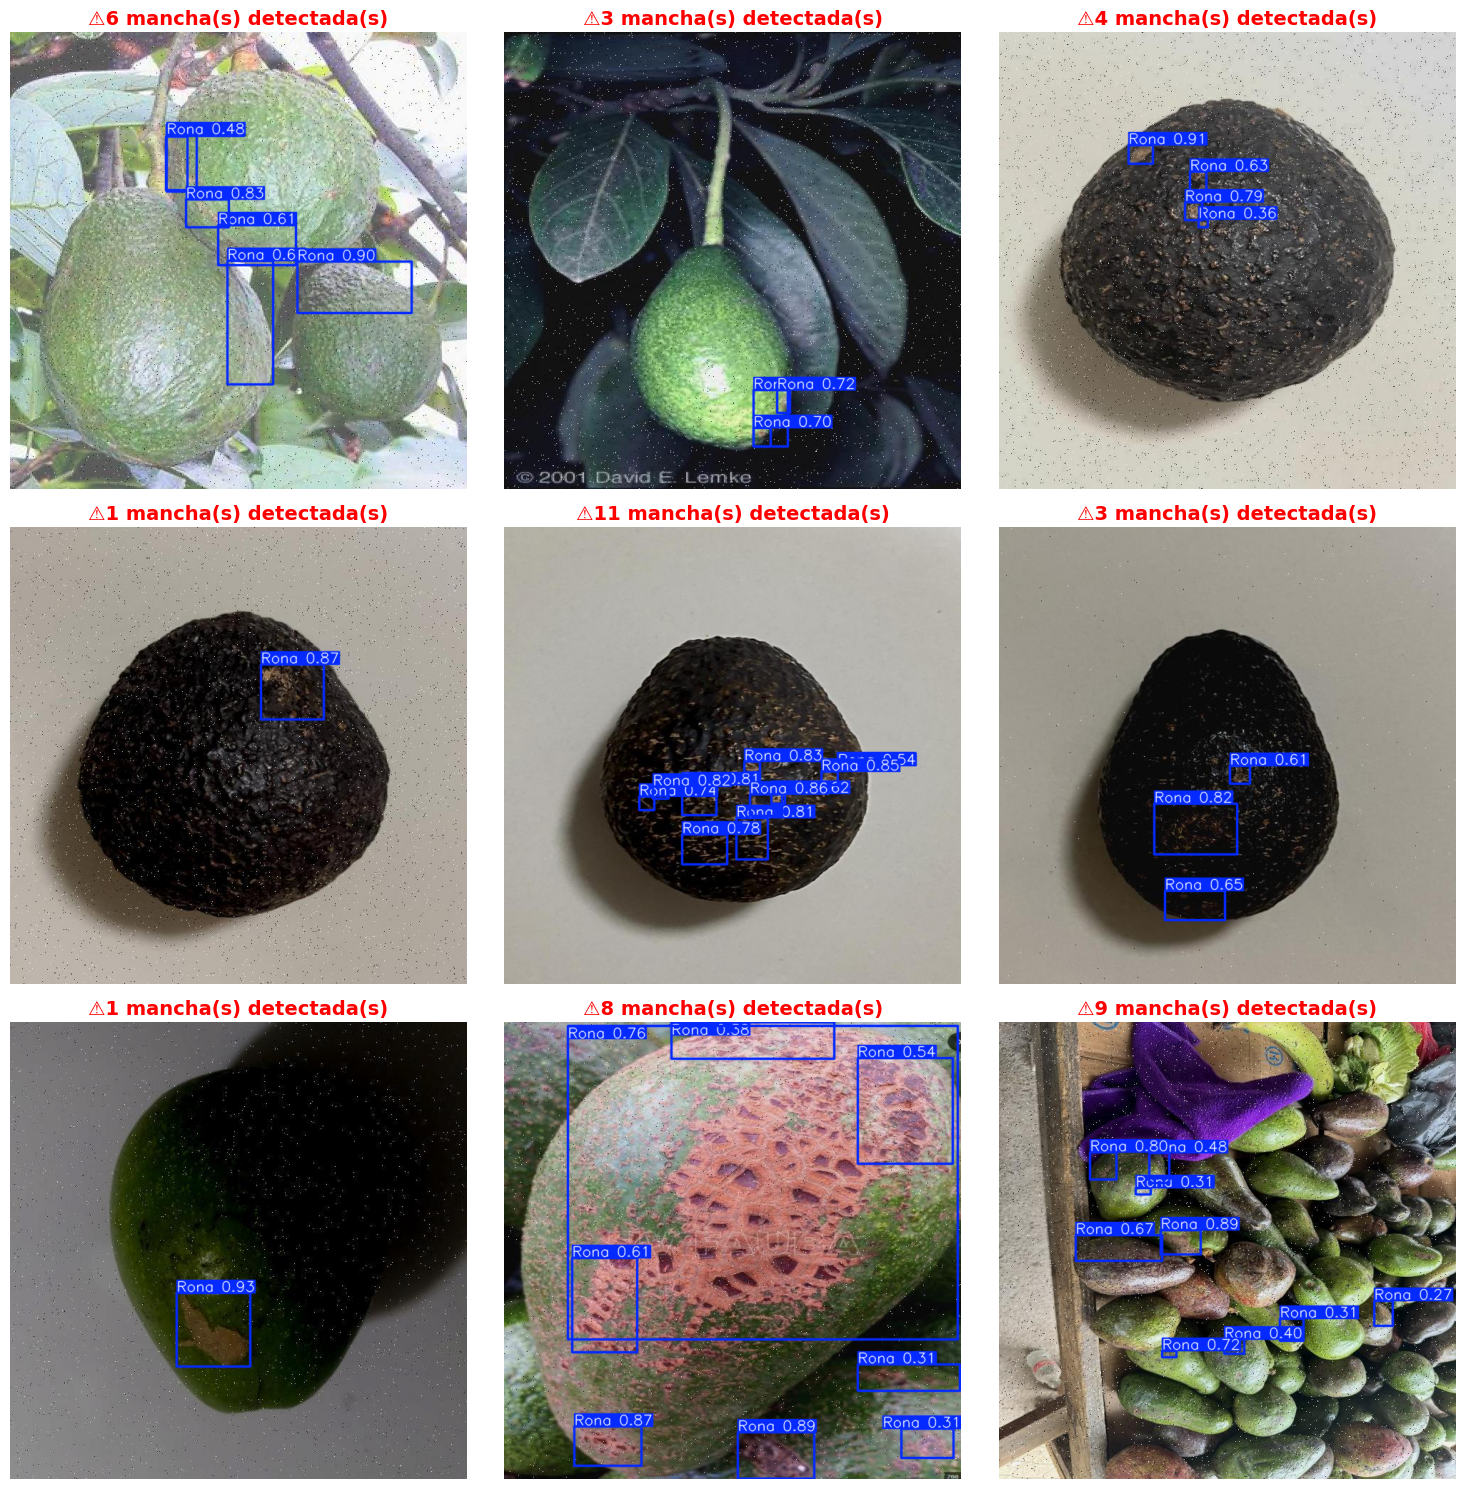

In [ ]:
!pip install ultralytics -q
import glob as gl
from ultralytics import YOLO

print("Modelo entrenado")

# Cargar modelo
test_model = YOLO('/content/drive/MyDrive/6TO SEMESTRE/DESARROLLO DE SOFTWARE II/model-v2/best_v2.pt')

# Buscar fotos en el dataset
image_path= f"{dataset.location}/valid/images/*.jpg"
image_list = gl.glob(image_path)

# Si las el formato es .png u otro formato, y no se encontró .jpg:
if len(image_list) == 0:
    image_list= gl.glob(f"{dataset.location}/valid/images/*")

if len(image_list) == 0:
    print("No se encontró la ruta")
else:
    print(f"Hay  {len(image_list)} imágenes para hacer pruebas")

    # escoger 9 fotos al azar para la cuadrícula
    number = min(9, len(image_list))
    random_image = random.sample(image_list, number)

    #analizar las imágenes con yolo
    results = test_model.predict(random_image, conf=0.25)

    print("\nCuadro de resultados ")

    # Graficar las imagenes
    plt.figure(figsize=(15, 15))

    for i, result in enumerate(results):
        plt.subplot(3, 3, i + 1)

        # .plot() que devuelve la foto ya rayada
        img_box= result.plot()

        # Invertimos los colores de BGR a RGB para Matplotlib
        img_rgb = cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB)

        plt.imshow(img_rgb)
        plt.axis('off')

        # Contar cuántas manchas encontraron en esta foto
        stain_num = len(result.boxes)
        if stain_num > 0:
            plt.title(f"⚠️{stain_num} mancha(s) detectada(s)", color='red', fontweight='bold', fontsize=14)
        else:
            plt.title("🟢Sano / Nada detectado", color='green', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()

### 🚀 Cómo activar la GPU en Google Colab

Sigue estos pasos para acelerar el entrenamiento de tu modelo:

1. En el menú superior, ve a **Entorno de ejecución** (Runtime).
2. Selecciona **Cambiar tipo de entorno de ejecución** (Change runtime type).
3. En el desplegable de **Acelerador de hardware** (Hardware accelerator), selecciona **T4 GPU**.
4. Haz clic en **Guardar** (Save).

*Nota: Colab reiniciará la sesión, por lo que es posible que debas volver a ejecutar las celdas de instalación e importación.*

In [ ]:
import torch

if torch.cuda.is_available():
    print(f"GPU activa: {torch.cuda.get_device_name(0)}")
else:
    print("La GPU no está activa")

GPU activa: Tesla T4


In [6]:
import os
from google.colab import files

# El modelo fue guardado previamente en Google Drive en esta ruta
path_in_drive = '/content/drive/MyDrive/6TO SEMESTRE/DESARROLLO DE SOFTWARE II/model-v2/best_v2.pt'

# Comprobar si el archivo existe antes de intentar descargarlo
if os.path.exists(path_in_drive):
    files.download(path_in_drive)
    print(f"Descargando el modelo de Google Drive: {path_in_drive}")
else:
    print(f"Error: El archivo no fue encontrado en Google Drive en la ruta especificada: {path_in_drive}")
    print("Por favor, verifica tu Google Drive para asegurarte de que el archivo existe y la ruta es correcta.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando el modelo de Google Drive: /content/drive/MyDrive/6TO SEMESTRE/DESARROLLO DE SOFTWARE II/model-v2/best_v2.pt
